# 沐曦GPU运行nnUNet说明文档
[nnU-Net](https://github.com/MIC-DKFZ/nnUNet.git) 是一个能够针对特定数据集自动适配流程的语义分割框架。它通过分析训练数据、生成数据集指纹，自动配置最合适的`U-Net`变体，并提供从数据预处理、模型训练、模型筛选到推理预测的一站式端到端解决方案。

## 1. 安装
### 1.1 环境准备
使用沐曦开发者社区提供的[maca-pytorch镜像](https://developer.metax-tech.com/softnova/docker?chip_name=%E6%9B%A6%E4%BA%91C500%E7%B3%BB%E5%88%97&package_name=maca-pytorch:3.8.0.11-torch2.6-py310-ubuntu24.04-amd64)启动容器：

```bash
docker run -it --name test-nnunet --device=/dev/mxcd --device=/dev/dri --group-add video --shm-size=8G --security-opt seccomp=unconfined --ulimit memlock=-1  --ulimit stack=67108864 -v /workspace:/workspace cr.metax-tech.com/public-library/maca-pytorch:3.8.0.11-torch2.6-py310-ubuntu24.04-amd64 /bin/bash
```
**参数说明：**
- `--device=/dev/mxcd --device=/dev/dri`：挂载沐曦GPU设备
- `--group-add video`：添加video组以访问GPU
- `--shm-size=8G`：设置共享内存大小
- `-v`：挂载工作目录

> 如需使用更新版本，请访问[沐曦开发者|镜像资源中心](https://developer.metax-tech.com/softnova/docker/)获取对应资源。
### 1.2 安装nnUNet
安装流程与官方文档保持一致。用户可通过执行`pip install nnunetv2`完成标准部署；若需进行二次开发或本地调试，建议采用可编辑模式安装，具体命令如下：

In [ ]:
%%bash
#apt update && apt install git -y
cd /opt 
git clone https://github.com/MIC-DKFZ/nnUNet.git
cd nnUNet
git rev-parse HEAD
pip install -e .

1.3 环境验证

In [3]:
!pip show nnunetv2
import torch
assert torch.cuda.is_available()
print('PyTorch version:', torch.__version__)
print('CUDA OK:', torch.cuda.get_device_name(0))

Name: nnunetv2
Version: 2.8.1
Summary: nnU-Net is a framework for out-of-the box image segmentation.
Home-page: https://github.com/MIC-DKFZ/nnUNet
Author: Helmholtz Imaging Applied Computer Vision Lab
Author-email: Fabian Isensee <f.isensee@dkfz-heidelberg.de>
License: Apache License
                                   Version 2.0, January 2004
                                http://www.apache.org/licenses/
        
           TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION
        
           1. Definitions.
        
              "License" shall mean the terms and conditions for use, reproduction,
              and distribution as defined by Sections 1 through 9 of this document.
        
              "Licensor" shall mean the copyright owner or entity authorized by
              the copyright owner that is granting the License.
        
              "Legal Entity" shall mean the union of the acting entity and all
              other entities that control, are controlle

## 2. 沐曦GPU 运行效果展示（benchmarks测试）
`nnU-Net`的基准测试会对模型进行 5 个 Epoch 的训练。详细介绍参见[benchmarking.md](https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/benchmarking.md)。[数据集下载链接](https://drive.google.com/drive/folders/1HqEgzS8BV2c7xYNrZdEAnrHk7osJJ--2)。以下命令对`Tasks 2`数据集进行操作，并且假设数据集已经下载到`/root/Task02_Heart`
> 为提升 `Conv3D` 在沐曦 GPU 上的性能,请设置环境变量：export PYTORCH_DEFAULT_NDHWC=1

In [4]:
%%bash
export PYTORCH_DEFAULT_NDHWC=1
export nnUNet_raw=/opt/Task02_Heart_raw
export nnUNet_preprocessed=/opt/Task02_Heart_preprocessed
export nnUNet_results=/opt/Task02_Heart_results
export nnUNet_compile=f
nnUNetv2_convert_MSD_dataset -i /root/Task02_Heart           
nnUNetv2_plan_and_preprocess -d 2 --verify_dataset_integrity
DATSET_ID=2
nnUNetv2_train $DATSET_ID 2d 0 -tr nnUNetTrainerBenchmark_5epochs
nnUNetv2_train $DATSET_ID 3d_fullres 0 -tr nnUNetTrainerBenchmark_5epochs
nnUNetv2_train $DATSET_ID 2d 0 -tr nnUNetTrainerBenchmark_5epochs_noDataLoading
nnUNetv2_train $DATSET_ID 3d_fullres 0 -tr nnUNetTrainerBenchmark_5epochs_noDataLoading

Fingerprint extraction...
Dataset002_Heart
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer


Extracting dataset fingerprint: 100%|██████████| 20/20 [00:03<00:00,  6.40it/s]


Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [115. 320. 232.], 3d_lowres: [115, 320, 232]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 40, 'patch_size': (320, 256), 'median_image_size_in_voxels': array([320., 232.]), 'spacing': array([1.25, 1.25]), 'normalization_schemes': ['ZScoreNormalization'], 'use_mask_for_norm': [True], 'resampling_fn_data': 'resample_data_or_seg_to_shape', 'resampling_fn_seg': 'resample_data_or_seg_to_shape', 'resampling_fn_data_kwargs': {'is_seg': False, 'order': 3, 'order_z': 0, 'force_separate_z': None}, 'resampling_fn_seg_kwargs': 

Preprocessing cases: 100%|██████████| 20/20 [00:04<00:00,  4.14it/s]


Configuration: 3d_fullres...
{'data_identifier': 'nnUNetPlans_3d_fullres', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 2, 'patch_size': [80, 192, 160], 'median_image_size_in_voxels': [115.0, 320.0, 232.0], 'spacing': [1.3700000047683716, 1.25, 1.25], 'normalization_schemes': ['ZScoreNormalization'], 'use_mask_for_norm': [True], 'resampling_fn_data': 'resample_data_or_seg_to_shape', 'resampling_fn_seg': 'resample_data_or_seg_to_shape', 'resampling_fn_data_kwargs': {'is_seg': False, 'order': 3, 'order_z': 0, 'force_separate_z': None}, 'resampling_fn_seg_kwargs': {'is_seg': True, 'order': 1, 'order_z': 0, 'force_separate_z': None}, 'resampling_fn_probabilities': 'resample_data_or_seg_to_shape', 'resampling_fn_probabilities_kwargs': {'is_seg': False, 'order': 1, 'order_z': 0, 'force_separate_z': None}, 'architecture': {'network_class_name': 'dynamic_network_architectures.architectures.unet.PlainConvUNet', 'arch_kwargs': {'n_stages': 6, 'features_per_stage': [32, 64, 128, 256,

Preprocessing cases: 100%|██████████| 20/20 [00:05<00:00,  3.91it/s]


Configuration: 3d_lowres...
INFO: Configuration 3d_lowres not found in plans file nnUNetPlans.json of dataset Dataset002_Heart. Skipping.

############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-08-11 02:21:27.122449: do_dummy_2d_data_aug: False
2026-08-11 02:21:27.122650: Creating new 5-fold cross-validation split...
2026-08-11 02:21:27.123105: 

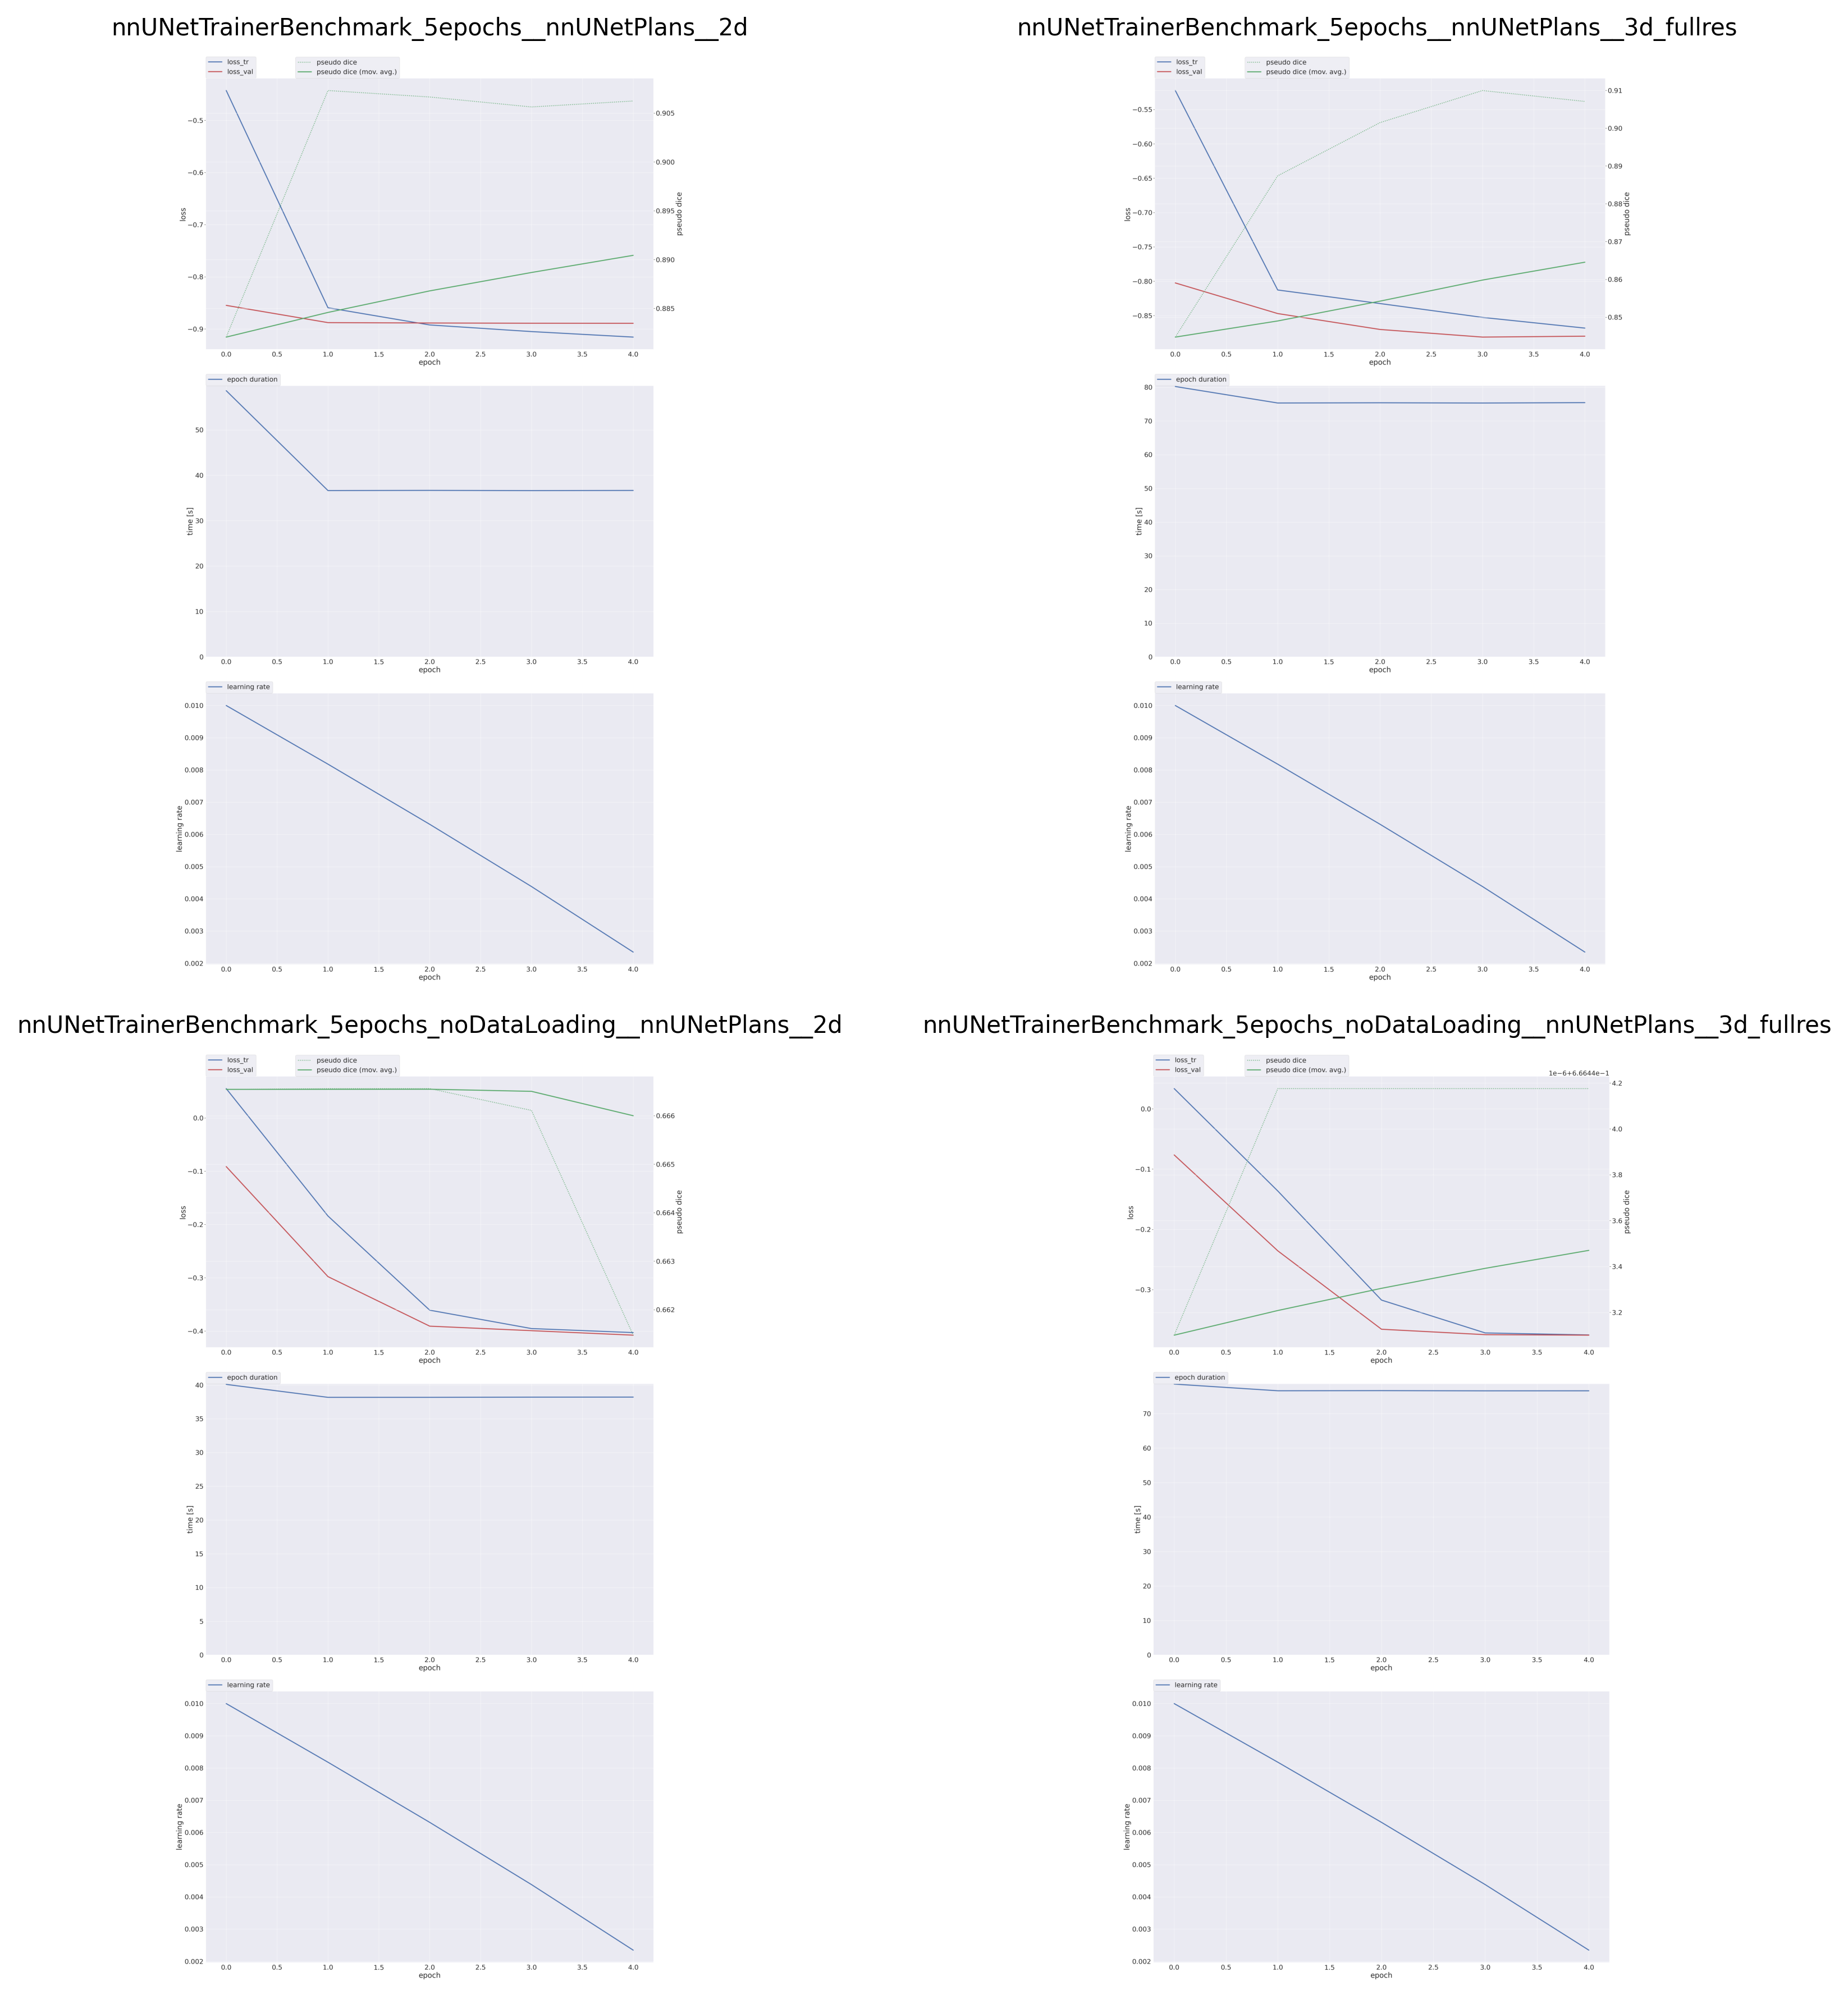

In [11]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

BASE = Path("/opt/Task02_Heart_results/Dataset002_Heart")


subdirs = sorted([p for p in BASE.iterdir() if p.is_dir()])

imgs, titles = [], []
for d in subdirs:
    png = d / "fold_0" / "progress.png"
    if not png.exists():
        raise FileNotFoundError(f"Cannot find {png}")
    imgs.append(mpimg.imread(png))
    titles.append(d.name)          

fig, axes = plt.subplots(2, 2, figsize=(14, 12),dpi=300)
for ax, img, title in zip(axes.flat, imgs, titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=10, wrap=True)
    ax.axis("off")

plt.tight_layout()
plt.show()

---
本文档仅提供相关软件的配置与使用说明，不包含亦不分发前述软件的源代码或目标代码，且不涉及对其源代码的任何修改。您按照本文档配置、部署或使用相关软件时，应遵守适用许可证规定的条款及条件。相关软件的源代码、许可证全文、版权与归属声明及其他项目文档，请以其官方网站或原始发布页面为准。

### Copyright (c) 2026 MetaX Integrated Circuits (Shanghai) Co., Ltd. All rights reserved.